# Goal:

This notebook is the second part of the series of notebooks we are doing to test our algorithm in known cases. 

Here, the goal is to use known channels and reconstruct them (similar to `2q_target.ipynb`)

Let's just do tensor products of depolarizing and amplitude damping channels?

In [86]:
import jax.numpy as jnp

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import target_kraus_tensor_from_configuration, kraus_tensor_to_mgst, get_compressed_rep_from_mgst_output, get_compressed_perturbed_kraus_from_superop, get_compressed_perturbed_rep_from_mgst
from mGST.simulate import amplitude_damping_kraus_operators, get_initial_state_and_measurement, apply_single_superop_to_povm_tensor, apply_single_superop_to_state_matrix, generate_sequence_indices, compute_probability_matrices
from mGST.gauge_analysis import max_num_parameters, min_num_parameters
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.visualization import plot_cost_function

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create gate set (target and noisy)

In [67]:
num_sequences = 1000
num_shots = 1000
seq_len_list = [1, 8, 14]
num_qubits = 2
dim = 2 ** num_qubits
state_rank = dim
povm_rank = dim
backend = "iqmfakeapollo"

In [58]:
configuration = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_sequences,
    shots=num_shots,
    rank=1,
)

kraus_tensor_target, gate_labels = target_kraus_tensor_from_configuration(configuration, backend)
# (num_gates, kraus_rank, dim_out, dim_in)
kraus_tensor_target.shape, gate_labels

((6, 1, 4, 4),
 {'[0, 1]': {0: 'Idle:QB1',
   1: 'Rx_pi_2:QB1',
   2: 'Rx_pi_2:QB2',
   3: 'Ry_pi_2:QB1',
   4: 'Ry_pi_2:QB2',
   5: 'cz:QB1__QB2'}})

In [33]:
# kraus operators for amplitude damping channel
noise_strength = 1e-4
ad_channel_2q = amplitude_damping_kraus_operators(gamma=noise_strength, num_qubits=2)

# NOTE: didn't do separate ones just for ease of contraction. Could do this for funsies.
# ad_channel_cz = amplitude_damping_kraus_operators(gamma=noise_strength_cz, num_qubits=2)
print(ad_channel_2q.shape) # (kraus_rank, dim_out, dim_in)

(4, 4, 4)


In [34]:
# prune the rank 1 of the unitary tensor for simplicity of contraction
gate_set_unitary_rank_3 = jnp.squeeze(kraus_tensor_target, axis=1) # (num_gates, dim_out, dim_in) 
# now let's combine them 
noisy_kraus_tensor = jnp.einsum('kij, ljm->lkim', ad_channel_2q, gate_set_unitary_rank_3)
noisy_kraus_tensor.shape # (num_gates, kraus_rank, dim_out, dim_in)

(6, 4, 4, 4)

In [38]:
num_gates, kraus_rank = noisy_kraus_tensor.shape[:2]

In [63]:
# let's obtain the superoperator versions for all 3
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_superop_noisy = kraus_tensor_to_mgst(noisy_kraus_tensor)
kraus_superop_ad_channel = kraus_tensor_to_mgst(ad_channel_2q.reshape((1, *ad_channel_2q.shape)))
assert (kraus_superop_ad_channel.shape == (1, dim**2, dim**2)) # (num_gates, dim_out*dim_out, dim_in*dim_in)
assert (kraus_superop_target.shape == kraus_superop_noisy.shape == (num_gates, dim**2, dim**2)) # (num_gates, dim_out*dim_out, dim_in*dim_in)

In [64]:
# now the povm and state
state_target_matrix, povm_target_tensor = get_initial_state_and_measurement(dim=dim)
state_target_matrix.shape, povm_target_tensor.shape # (dim, dim), (kraus_rank, dim_out, dim_in)

((4, 4), (4, 4, 4))

In [65]:
# now let's obtain their noisy versions by applying the superoperators to them
state_matrix_noisy = apply_single_superop_to_state_matrix(state_matrix=state_target_matrix, superop=kraus_superop_ad_channel)
povm_tensor_noisy = apply_single_superop_to_povm_tensor(povm_tensor=povm_target_tensor, superop=kraus_superop_ad_channel)

# Get compressed versions

In [70]:
state_vect_target = state_target_matrix.reshape(-1) # (dim*dim,)
povm_vect_target = povm_target_tensor.reshape(povm_target_tensor.shape[0], -1) # (kraus_rank, dim_out*dim_in)

state_vect_noisy = state_matrix_noisy.reshape(-1) # (dim*dim,)
povm_vect_noisy = povm_tensor_noisy.reshape(povm_tensor_noisy.shape[0], -1) # (kraus_rank, dim_out*dim_in)

print(state_vect_target.shape, povm_vect_target.shape)

(16,) (4, 16)


In [71]:
# first the target
kraus_tensor_target, povm_psd_target, state_psd_target = get_compressed_rep_from_mgst_output(kraus_superop_target, povm_vect_target, state_vect_target, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

# now the noisy versions for the simulation
kraus_tensor_2q_noisy, povm_psd_2q_noisy, state_psd_2q_noisy = get_compressed_rep_from_mgst_output(kraus_superop_noisy, povm_vect_noisy, state_vect_noisy, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

In [78]:
# finally, let's use the noisy versions to obtain the probabilities.
indices_dict = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences, seq_len_list=seq_len_list)
indices_list = indices_dict["gate_indices"]

probability_matrices = compute_probability_matrices(kraus_tensor=kraus_tensor_2q_noisy, povm_psd=povm_psd_2q_noisy, state_psd=state_psd_2q_noisy, gate_indices=indices_list, num_shots=num_shots, seed=42)
probability_matrices.keys()

dict_keys(['exact', 'sampled'])

# Initial tensors

Based on the results from the `2q_target` notebook, we only perturb the kraus tensor.

In [83]:
kraus_tensor_init_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=kraus_rank, seed=42)
kraus_tensor_init = kraus_tensor_init_dict["kraus_tensor"]


povm_psd_init, state_psd_init = get_compressed_perturbed_rep_from_mgst(povm_vect_target, state_vect_target, rank_povm=povm_rank, rank_state=state_rank)

init_operators = {
    "kraus_tensor_init": kraus_tensor_init,
    "povm_psd_init": povm_psd_init,
    "state_psd_init": state_psd_init,
}

prob_matrix = probability_matrices["sampled"]
cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

print(f"shapes: {[v.shape for v in init_operators.values()]}")

shapes: [(6, 4, 4, 4), (4, 4, 4), (4, 4)]


# Optimization

## number of parameters estimation

In [82]:
# what are the max and min number of parameters for this configuration?
upper_bound = max_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)
lower_bound = min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

print(f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")

Upper bound: 815, Lower bound: 623


## initial cost

In [85]:
initial_cost_value = cost_function_jax_mps(*init_operators.values(), **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 43 the new count changed to: 4
at iteration 119 the new count changed to: 5
at iteration 195 the new count changed to: 6
at iteration 271 the new count changed to: 7
at iteration 347 the new count changed to: 8
at iteration 423 the new count changed to: 9
at iteration 500 the new count changed to: 10
at iteration 583 the new count changed to: 11
at iteration 666 the new count changed to: 12
at iteration 749 the new count changed to: 13
at iteration 832 the new count changed to: 14
at iteration 916 the new count changed to: 15
Initial cost value: 0.0011451715905203771


## setup

In [87]:
num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1 # before by mistake we set it to 0.5 (WRONG)

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

relative_precision = 1e-5

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

In [88]:
noise_floor = estimate_noise_floor_threshold(probability_matrix=prob_matrix, num_shots=num_shots, multiplier=1.0)
noise_floor

Array(0.00013888, dtype=float64)

## Run

In [89]:
optimized_operators, cost_fn_history = run_riemannian_optimization(
    **init_operators,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=None,
    relative_precision=relative_precision,
    verbose=True,
) # 15m 10.5s

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.145172e-03. |r∇f(x)|: 5.173766e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.726082e-04. |r∇f(x)|: 7.126240e-04. Radius: 2.00e-01
TCG finished after: 4/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 2.42e-07
---------------------------------------
TR Iteration: 2. f(x): 8.656881e-04. |r∇f(x)|: 1.079458e-06. Radius: 2.00e-01
TCG finished after: 10/10 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 7.448350e-09
Optimization finished ✅. 
 I

## plotting

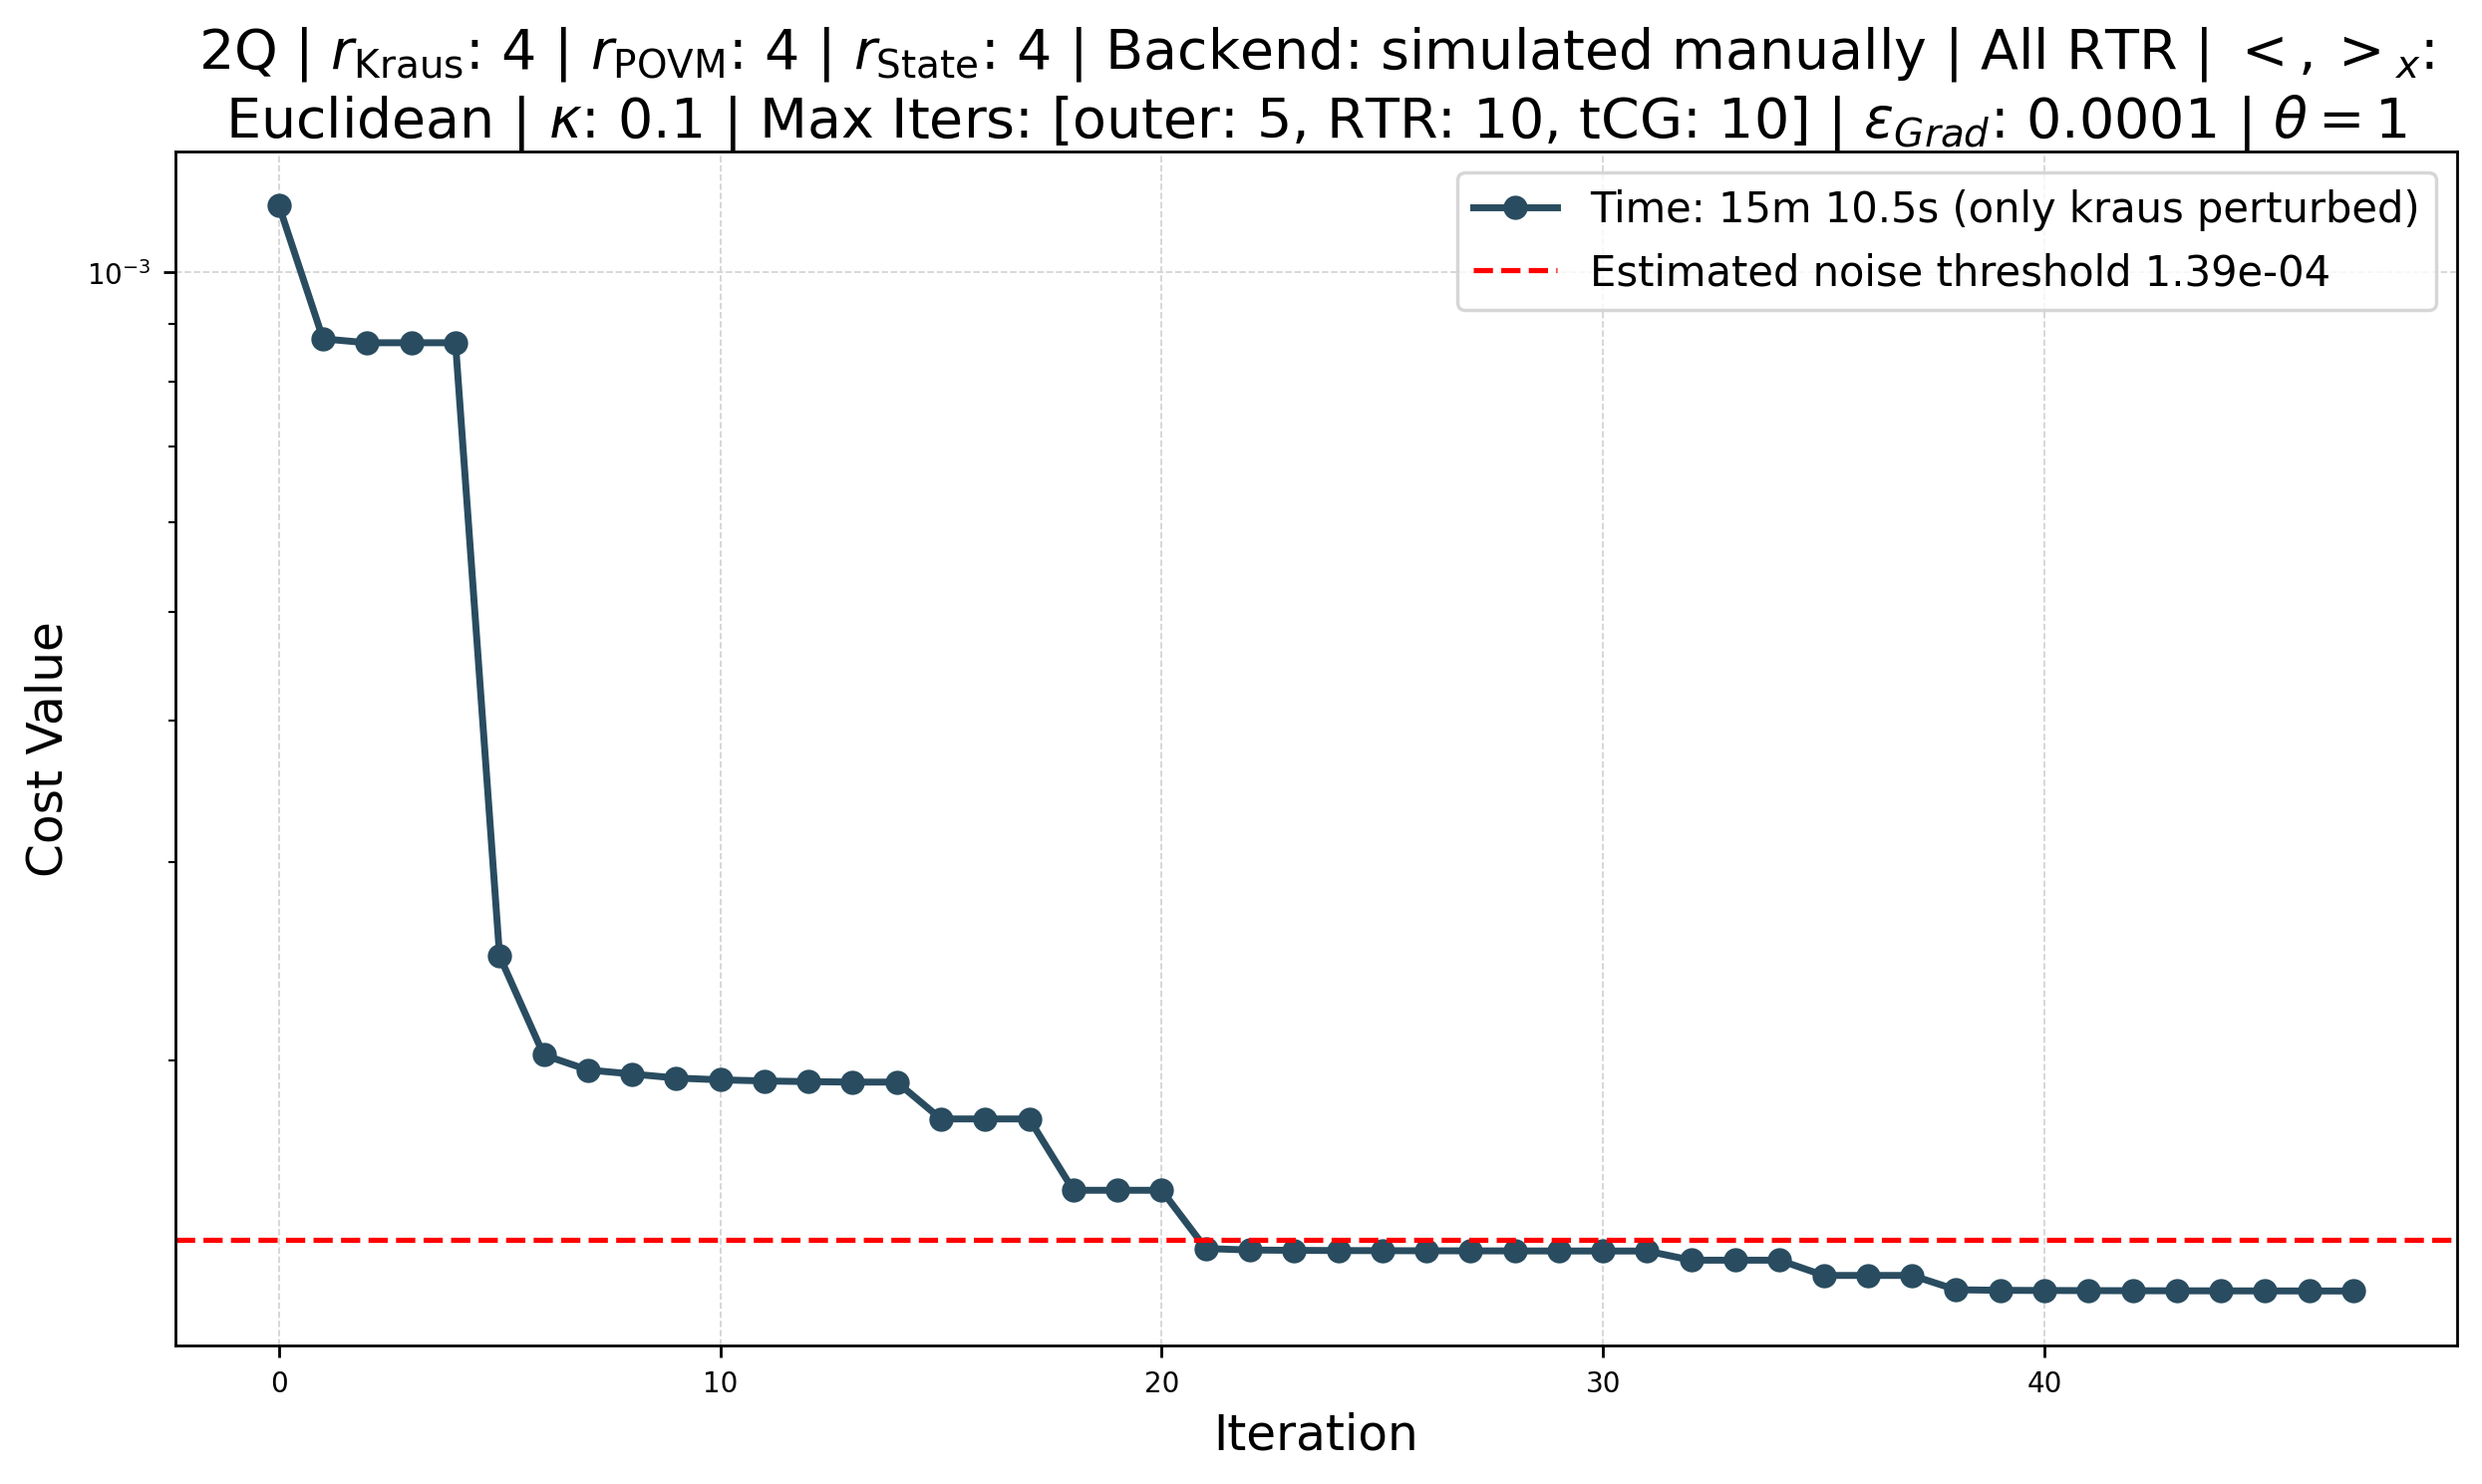

In [90]:
cost_fn_lists_ranks = [
    cost_fn_history,
]

time = "15m 10.5s"

labels_ranks = [
    rf"Time: {time} (only kraus perturbed)",
]

title_ranks = rf"2Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: simulated manually | All RTR | $<,>_x$: Euclidean | $\kappa$: {kappa} | Max Iters: [outer: {num_iterations_outer}, RTR: {num_iterations_tr}, tCG: {num_iterations_cg}] | $\epsilon_{{Grad}}$: {tol_grad} | $\theta=${theta}"

plot_cost_function(cost_fn_lists_ranks, title=title_ranks, labels=labels_ranks, comparison_yline=noise_floor, comparison_label=f"Estimated noise threshold {noise_floor:.2e}")

In [91]:
cost_fn_history[0], cost_fn_history[-1]

(Array(0.00114517, dtype=float64), Array(0.00012499, dtype=float64))

# Gauge optimization

In [92]:
from mGST.reporting.reporting import gauge_opt
from mGST.compatibility import arrays_to_pygsti_model
from mGST.utility_functions_comparisons import get_mgst_tensors_from_psd_representation

In [93]:
# The target model is the mgst tensors obtained in the beginning without perturbation
target_ops = {
    "X": kraus_superop_target,
    "E": povm_vect_target,
    "rho": state_vect_target
}
target_model_pygsti = arrays_to_pygsti_model(**target_ops, basis="std")
gauge_weights = dict({f"G%i" % i: 1 for i in range(num_gates)}, **{"spam": 0.1})

In [94]:
optimized_superops = get_mgst_tensors_from_psd_representation(*optimized_operators.values())

kraus_superop_gauged, povm_vect_gauged, state_vect_gauged = gauge_opt(X=optimized_superops["kraus"], E=optimized_superops["povm"], rho=optimized_superops["state"], target_mdl=target_model_pygsti, weights=gauge_weights)

# Error metrics

In [95]:
from mGST.reporting.reporting import report
import numpy as np

In [99]:
indices_list_with_padding = indices_dict['gate_indices_with_negs']
indices_list_with_padding.shape

(1000, 14)

In [187]:
# optimized-gauged operators
data_frame_gate_quality, date_frame_rest = report(
    X = kraus_superop_gauged,
    E = povm_vect_gauged,
    rho= state_vect_gauged,
    J=indices_list_with_padding,
    y=prob_matrix,
    target_mdl=target_model_pygsti,
    gate_labels=gate_labels
)


# initial operators
superops_initial = get_mgst_tensors_from_psd_representation(*init_operators.values())
print(superops_initial.keys())

data_frame_gate_quality_initial, date_frame_rest_initial = report(
    *superops_initial.values(),
    J=indices_list_with_padding,
    y=prob_matrix,
    target_mdl=target_model_pygsti,
    gate_labels=gate_labels
)

dict_keys(['kraus', 'povm', 'state'])


In [102]:
data_frame_gate_quality_initial

,F_avg,Diamond distances,Min. Spectral distances
0,0.997217,0.036713,0.029073
1,0.997217,0.036713,0.018075
2,0.997217,0.036712,0.022345
3,0.997217,0.036711,0.022636
4,0.997217,0.036713,0.021226
5,0.997217,0.036713,0.013872


In [101]:
data_frame_gate_quality

,F_avg,Diamond distances,Min. Spectral distances
0,0.999613,0.004884,0.004055
1,0.999402,0.004479,0.001718
2,0.999101,0.005528,0.003531
3,0.999647,0.004624,0.003047
4,0.999366,0.004892,0.002761
5,0.999253,0.004744,0.002966


In [103]:
date_frame_rest_initial

,Final cost function value,Mean total variation dist. to data,Mean total variation dist. target to data,POVM - Meas. map diamond dist.,State - Trace dist.
,0.001145,0.048815,0.014986,6.558392e-26,1.988498e-14


In [188]:
date_frame_rest

,Final cost function value,Mean total variation dist. to data,Mean total variation dist. target to data,POVM - Meas. map diamond dist.,State - Trace dist.
,0.000125,0.015361,0.014986,0.008536,0.007367


## Comparison against noisy ones

In [107]:
# how far are we from the actual noisy superoperators?
# 1. Diamond norms
from qiskit.quantum_info import SuperOp
from qiskit.quantum_info.operators.measures import diamond_norm

In [109]:
type(kraus_superop_gauged), type(kraus_superop_noisy)

(numpy.ndarray, jaxlib.xla_extension.ArrayImpl)

In [114]:
kraus_superop_noisy_np = np.array(kraus_superop_noisy)
diamond_distances_optimized = [diamond_norm(SuperOp(kraus_superop_gauged[i]) - SuperOp(kraus_superop_noisy_np[i])) / 2 for i in range(num_gates)]

kraus_superops_initial = superops_initial["kraus"]
diamond_distances_originally = [diamond_norm(SuperOp(kraus_superops_initial[i]) - SuperOp(kraus_superop_noisy_np[i])) / 2 for i in range(num_gates)]

In [113]:
diamond_distances_optimized

[0.0048782045031211824,
 0.004487498448806316,
 0.005532462051040365,
 0.004625932875239413,
 0.004917146668612066,
 0.004695706853543001]

In [116]:
diamond_distances_originally

[0.03663911994045285,
 0.03664029688509088,
 0.036639068725109206,
 0.036639129488816514,
 0.03663652930936871,
 0.03663911994045378]

Most things seem actually very good. The diamond norm between the original and the optimized ones are very good. One remaining question is how this would change with less/more number of sequences?

# Full worklfow

In [141]:
def get_default_optimization_options():
    num_iterations_outer = 5
    num_iterations_tr = 10
    num_iterations_cg = 10
    tol_grad = 1e-4
    kappa = 1/10
    theta = 1 # before by mistake we set it to 0.5 (WRONG)
    
    tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

    optimization_schedule_all_tr = {
        "kraus": tr_schedule_verbose,
        "povm": tr_schedule_verbose,
        "state": tr_schedule_verbose
    }
    
    relative_precision = 1e-5
    
    return optimization_schedule_all_tr, num_iterations_outer, relative_precision


def check_operators_dictionaries(*dicts)-> None:
    """
    Check if all dictionaries have valid keys.
    """
    EXPECTED_KEYS = {"kraus", "povm", "state"}

    for dict in dicts:
        if set(dict.keys()) != EXPECTED_KEYS:
            raise ValueError(f"Dictionary keys {dict.keys()} do not match expected keys {EXPECTED_KEYS}.")


def run_optimization_workflow(num_sequences:int, num_shots:int, init_operators:dict[str, jnp.ndarray], operators_psd_noisy:dict[str, jnp.ndarray], target_superops:dict[str, jnp.ndarray]):


    check_operators_dictionaries(operators_psd_noisy, target_superops, init_operators)    
    
    seq_len_list = [1, 8, 14]
    kraus_tensor_noisy = operators_psd_noisy["kraus"]
    povm_psd_noisy = operators_psd_noisy["povm"]
    state_psd_noisy = operators_psd_noisy["state"]
    
    # we can get the number of gates from any of the kraus tensors
    num_gates = kraus_tensor_noisy.shape[0]
    
    # return this one
    indices_dict = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences, seq_len_list=seq_len_list)
    indices_list = indices_dict["gate_indices"]

    # return this one
    probability_matrices = compute_probability_matrices(kraus_tensor=kraus_tensor_noisy, povm_psd=povm_psd_noisy, state_psd=state_psd_noisy, gate_indices=indices_list, num_shots=num_shots, seed=42)
    
    probability_matrix_sampled = probability_matrices["sampled"]
    cost_fn_kwargs = {
        "indices_list": indices_list,
        "prob_matrix": probability_matrix_sampled,
        "jit": True,
    }
    
    optimization_schedule_all_tr, num_iterations_outer, relative_precision = get_default_optimization_options()
    
    # return these ones
    optimized_operators, cost_fn_history = run_riemannian_optimization(
        *init_operators.values(),
        cost_function=cost_function_jax_mps,
        cost_fn_kwargs=cost_fn_kwargs,
        num_iterations=num_iterations_outer,
        optimization_schedule=optimization_schedule_all_tr,
        save_intermediate_cost_values=True,
        noise_threshold=None,
        relative_precision=relative_precision,
        verbose=True,
    )
    
    kraus_superop_gauged, povm_vect_gauged, state_vect_gauged, target_model_pygsti = perform_gauge(optimized_operators=optimized_operators, target_superops=target_superops, num_gates=num_gates)
    
    superops_gauged = {
        "kraus": kraus_superop_gauged,
        "povm": povm_vect_gauged,
        "state": state_vect_gauged
    }
    
    return {"optimized_operators": optimized_operators, "superops_gauged": superops_gauged, "target_model_pygsti": target_model_pygsti, "cost_fn_history": cost_fn_history, "probability_matrices": probability_matrices, "indices_dict": indices_dict}
    
def perform_gauge(optimized_operators:dict[jnp.ndarray], target_superops:dict[jnp.ndarray], num_gates:int):
    """
    Perform gauge optimization on the optimized operators.
    """
    optimized_superops = get_mgst_tensors_from_psd_representation(*optimized_operators.values())
    
    gauge_weights = dict({f"G%i" % i: 1 for i in range(num_gates)}, **{"spam": 0.1})

    target_model_pygsti = arrays_to_pygsti_model(*target_superops.values(), basis="std")

    kraus_superop_gauged, povm_vect_gauged, state_vect_gauged = gauge_opt(X=optimized_superops["kraus"], E=optimized_superops["povm"], rho=optimized_superops["state"], target_mdl=target_model_pygsti, weights=gauge_weights)
    
    return kraus_superop_gauged, povm_vect_gauged, state_vect_gauged, target_model_pygsti

# 100 sequences

In [142]:
init_operators.keys()

dict_keys(['kraus_tensor_init', 'povm_psd_init', 'state_psd_init'])

In [143]:
init_operators_new = {
    "kraus": init_operators["kraus_tensor_init"],
    "povm": init_operators["povm_psd_init"],
    "state": init_operators["state_psd_init"]
}

operators_psd_noisy={
    "kraus": kraus_tensor_2q_noisy,
    "povm": povm_psd_2q_noisy,
    "state": state_psd_2q_noisy
}

target_superops={
    "kraus": kraus_superop_target,
    "povm": povm_vect_target,
    "state": state_vect_target
}

In [144]:
optimization_results_100_seq = run_optimization_workflow(
    num_sequences=100,
    num_shots=num_shots,
    init_operators=init_operators_new,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=target_superops
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.136022e-03. |r∇f(x)|: 5.627159e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.358635e-04. |r∇f(x)|: 1.054195e-03. Radius: 2.00e-01
TCG finished after: 5/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 9.51e-07
---------------------------------------
TR Iteration: 2. f(x): 8.181444e-04. |r∇f(x)|: 8.311944e-06. Radius: 2.00e-01
TCG finished after: 9/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 5.492928e-07
Optimization finished

In [169]:
optimization_results_200_seq = run_optimization_workflow(
    num_sequences=200,
    num_shots=num_shots,
    init_operators=init_operators_new,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=target_superops
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 9.873056e-04. |r∇f(x)|: 4.873164e-03. Radius: 1.00e-01
TCG finished after: 6/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 7.625733e-04. |r∇f(x)|: 9.239297e-05. Radius: 2.00e-01
TCG finished after: 6/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 7.85e-09
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 7.690602e-06
Optimization finished ✅. 
 Iters: 2. f(x): 7.624451e-04. |r∇f(x)|: 3.747756e-08. Radius: 2.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 2.25e-04. Target: 1.00e-05.
🚀 TR started for operat

In [170]:
optimization_results_300_seq = run_optimization_workflow(
    num_sequences=300,
    num_shots=num_shots,
    init_operators=init_operators_new,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=target_superops
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.114565e-03. |r∇f(x)|: 4.819840e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.737771e-04. |r∇f(x)|: 5.709822e-04. Radius: 2.00e-01
TCG finished after: 8/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 8.702224e-04. |r∇f(x)|: 5.320250e-05. Radius: 4.00e-01
TCG finished after: 9/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 3. f(x): 8.701879e-04. |r∇f(x)|: 1.618402e-06. Radius: 8.00e-01
TCG finished after: 4/1

In [208]:
optimization_results_700_seq = run_optimization_workflow(
    num_sequences=700,
    num_shots=num_shots,
    init_operators=init_operators_new,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=target_superops
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.178853e-03. |r∇f(x)|: 5.347361e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.850266e-04. |r∇f(x)|: 8.160629e-04. Radius: 2.00e-01
TCG finished after: 4/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 2.85e-07
---------------------------------------
TR Iteration: 2. f(x): 8.759162e-04. |r∇f(x)|: 1.557313e-06. Radius: 2.00e-01
TCG finished after: 10/10 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 1.109038e-08
Optimization finished ✅. 
 I

In [196]:
optimization_results_1000_seq = run_optimization_workflow(
    num_sequences=1000,
    num_shots=num_shots,
    init_operators=init_operators_new,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=target_superops
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.194699e-03. |r∇f(x)|: 5.379694e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 9.036323e-04. |r∇f(x)|: 9.464546e-04. Radius: 2.00e-01
TCG finished after: 4/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 6.79e-07
---------------------------------------
TR Iteration: 2. f(x): 8.900051e-04. |r∇f(x)|: 2.547921e-06. Radius: 2.00e-01
TCG finished after: 10/10 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 4.395460e-08
Optimization finished ✅. 
 I

In [ ]:
optimization_results_1200_seq = run_optimization_workflow(
    num_sequences=1200,
    num_shots=num_shots,
    init_operators=init_operators_new,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=target_superops
)

# 500 sequences

In [124]:
num_sequences_low = num_sequences // 2

In [127]:
indices_dict_low = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences_low, seq_len_list=seq_len_list)
indices_list_low = indices_dict_low["gate_indices"]

probability_matrices_low = compute_probability_matrices(kraus_tensor=kraus_tensor_2q_noisy, povm_psd=povm_psd_2q_noisy, state_psd=state_psd_2q_noisy, gate_indices=indices_list_low, num_shots=num_shots, seed=42)

probability_matrix_sampled_low = probability_matrices_low["sampled"]

cost_fn_kwargs_low = {
    "indices_list": indices_list_low,
    "prob_matrix": probability_matrix_sampled_low,
    "jit": True,
}

In [128]:
initial_cost_value_low = cost_function_jax_mps(*init_operators.values(), **cost_fn_kwargs_low)
print("Initial cost value:", initial_cost_value_low)

Initial cost value: 0.001146118595533946


In [ ]:
optimized_operators_low, cost_fn_history_low = run_riemannian_optimization(
    **init_operators,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_low,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=None,
    relative_precision=relative_precision,
    verbose=True,
) # 7m 38.4s

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.146119e-03. |r∇f(x)|: 4.847495e-03. Radius: 1.00e-01
TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 9.029438e-04. |r∇f(x)|: 6.057453e-04. Radius: 2.00e-01
TCG finished after: 8/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 8.981810e-04. |r∇f(x)|: 6.858989e-05. Radius: 4.00e-01
TCG finished after: 8/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 8.648226e-05
Optimization finished ✅. 
 Iters: 3

In [176]:
optimized_superops_low = get_mgst_tensors_from_psd_representation(*optimized_operators_low.values())

kraus_superop_gauged_low, povm_vect_gauged_low, state_vect_gauged_low = gauge_opt(X=optimized_superops_low["kraus"], E=optimized_superops_low["povm"], rho=optimized_superops_low["state"], target_mdl=target_model_pygsti, weights=gauge_weights)

# Comparisons

In [210]:
cost_fn_100_seq = optimization_results_100_seq["cost_fn_history"]
cost_fn_200_seq = optimization_results_200_seq["cost_fn_history"]
cost_fn_300_seq = optimization_results_300_seq["cost_fn_history"]
cost_fn_700_seq = optimization_results_700_seq["cost_fn_history"]
cost_fn_1000_seq = optimization_results_1000_seq["cost_fn_history"]

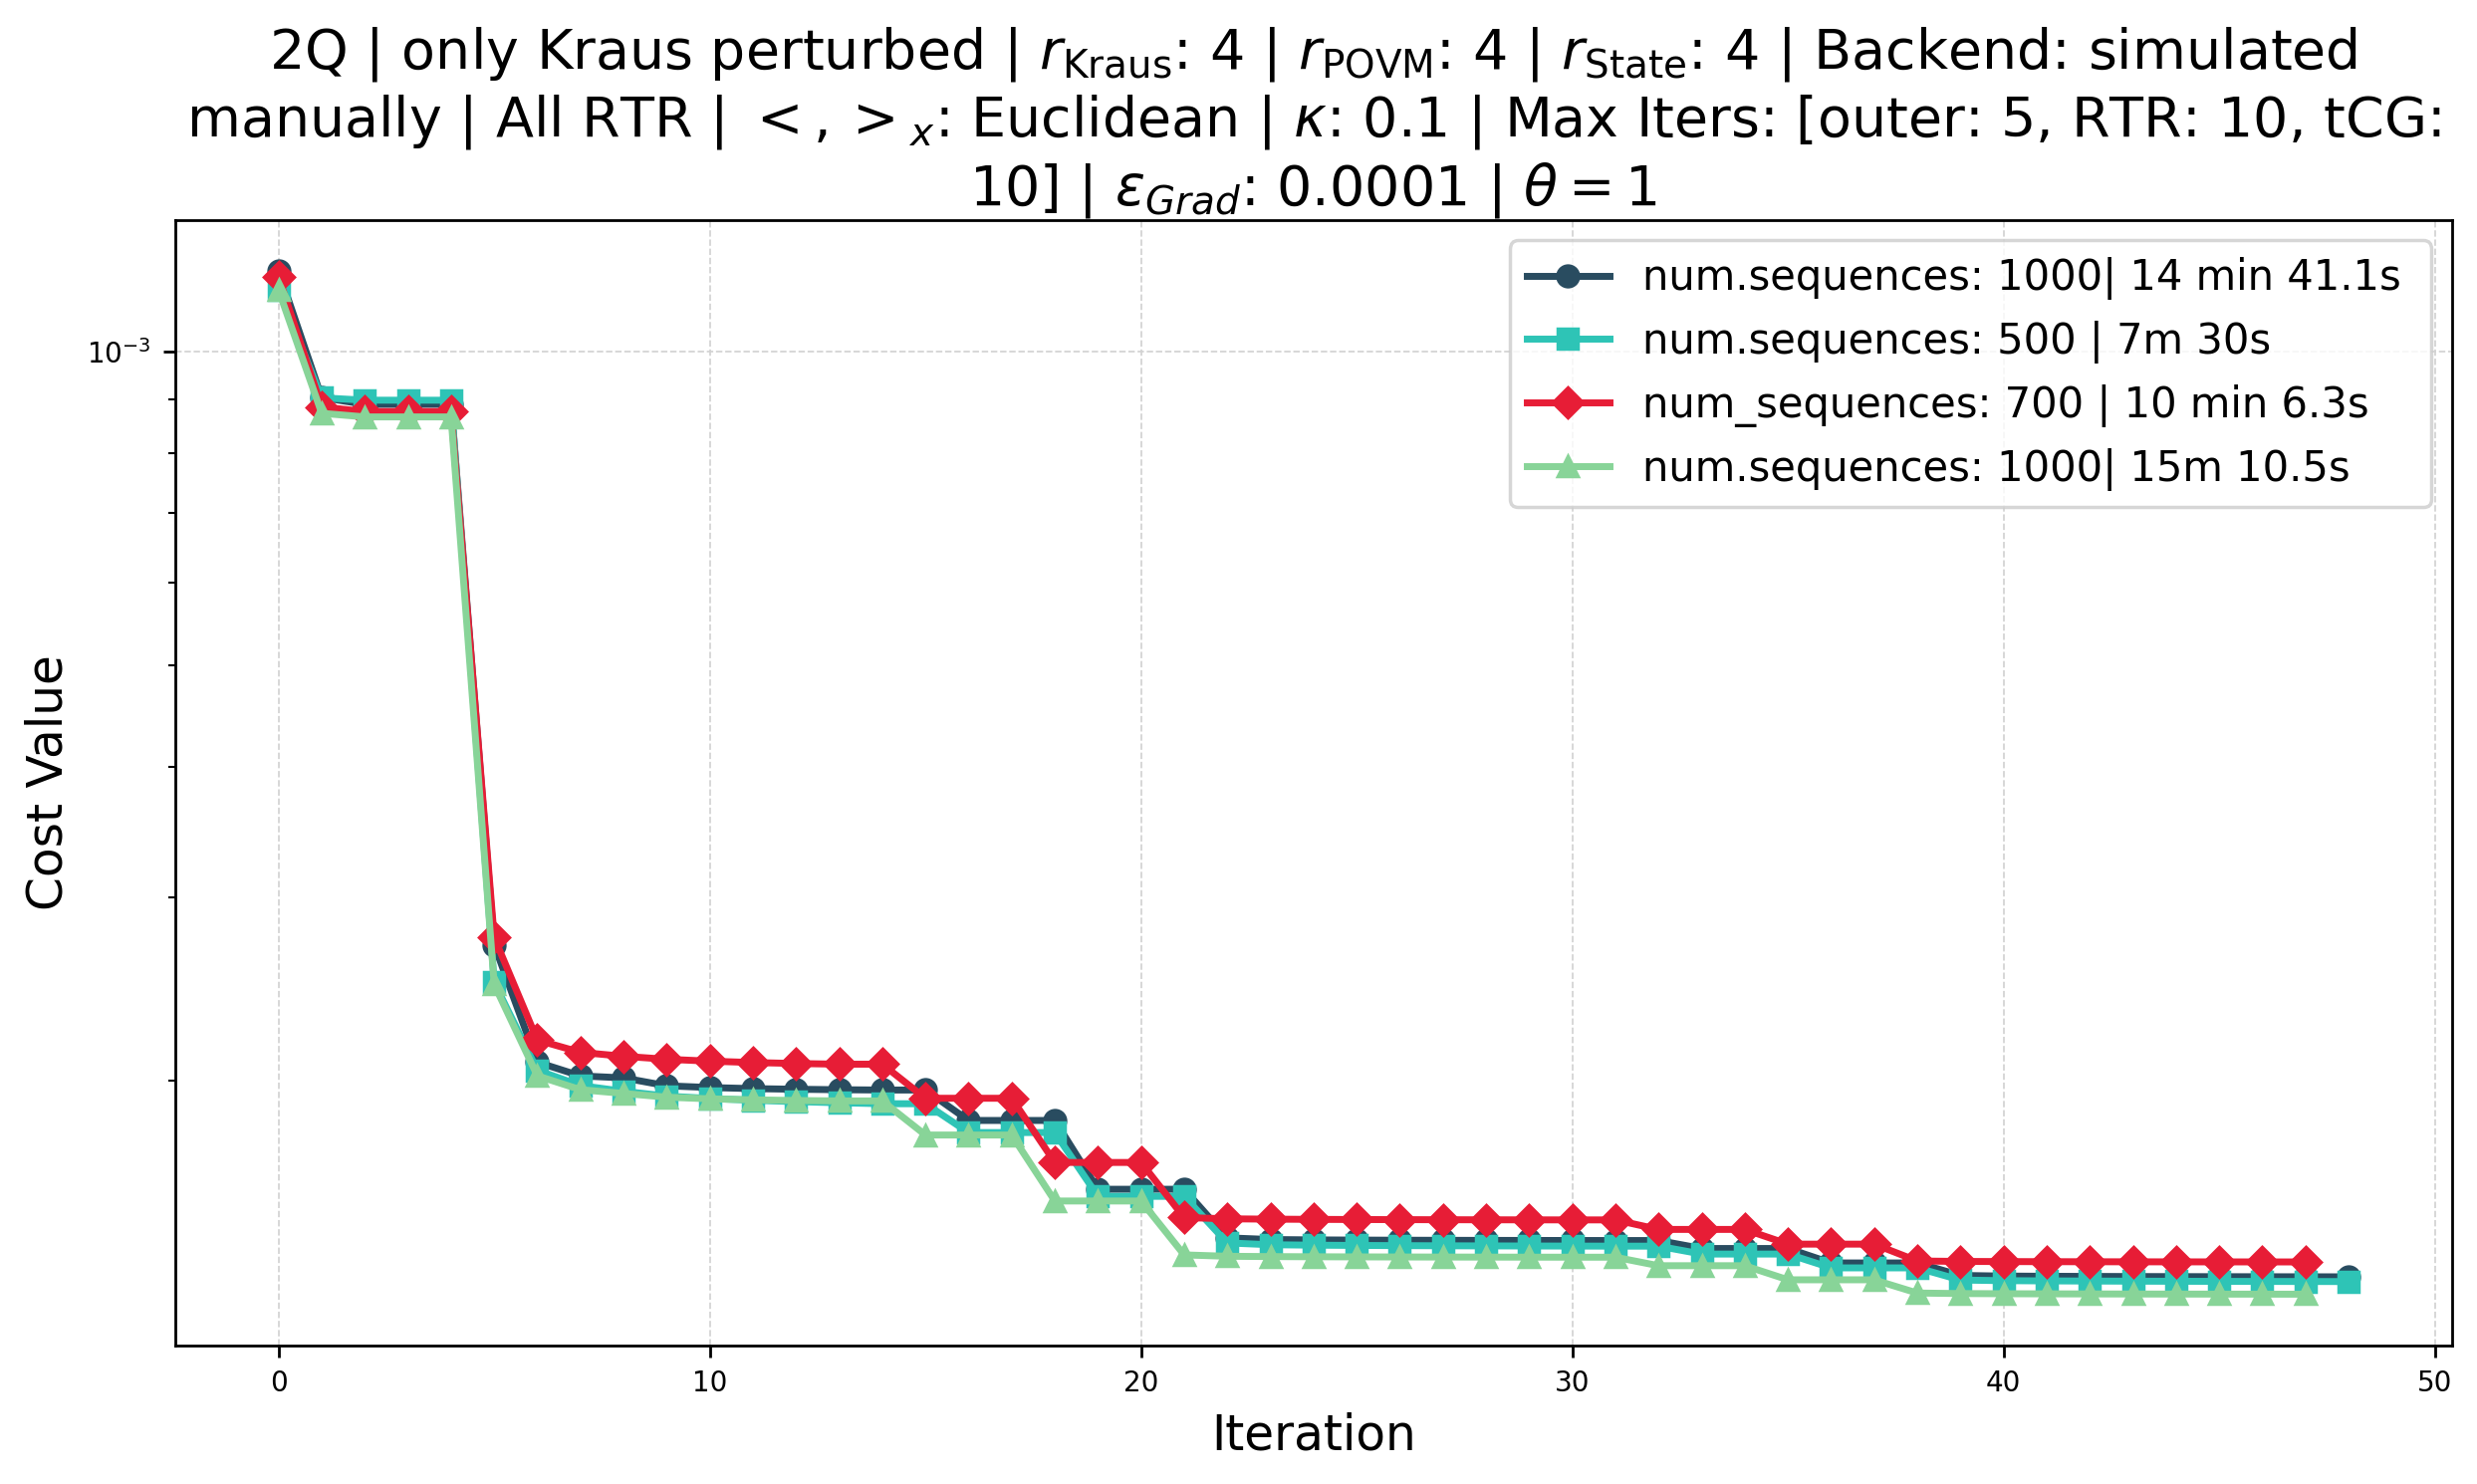

In [213]:
cost_fn_lists_ranks = [
    # cost_fn_100_seq,
    # cost_fn_200_seq,
    # cost_fn_300_seq,
    cost_fn_1000_seq,
    cost_fn_history_low,
    cost_fn_700_seq,
    cost_fn_history,
]

# time_100_seq = "1min 31s"
# time_200_seq = "2min 54.5s"
# time_300_seq = "4min 57.7s"
time_1000_seq = "14 min 41.1s"
time_low = "7m 30s"
time_700_seq = "10 min 6.3s"
time = "15m 10.5s"

labels_ranks = [
    # rf"num.sequences: 100 | {time_100_seq} ",
    # rf"num.sequences: 200 | {time_200_seq}",
    # rf"num.sequences: 300 | {time_300_seq}",
    rf"num.sequences: 1000| {time_1000_seq} ",
    rf"num.sequences: 500 | {time_low}",
    rf"num_sequences: 700 | {time_700_seq}",
    rf"num.sequences: 1000| {time} ",
]

title_ranks = rf"2Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: simulated manually | All RTR | $<,>_x$: Euclidean | $\kappa$: {kappa} | Max Iters: [outer: {num_iterations_outer}, RTR: {num_iterations_tr}, tCG: {num_iterations_cg}] | $\epsilon_{{Grad}}$: {tol_grad} | $\theta=${theta}"

plot_cost_function(cost_fn_lists_ranks, title=title_ranks, labels=labels_ranks, comparison_yline=None, comparison_label=f"Estimated noise threshold {noise_floor:.2e}")

In [185]:
def diamond_norm_distances(superop1, superop2):
    """
    Compute the diamond norm distance between two superoperators.
    """
    assert superop1.ndim == superop2.ndim == 3, "Superoperators must have the same number of dimensions."
    assert superop1.shape == superop2.shape, "Superoperators must have the same shape."
    num_gates = superop1.shape[0]
    return [diamond_norm(SuperOp(superop1[i]) - SuperOp(superop2[i])) / 2 for i in range(num_gates)]

from mGST.reporting.reporting import MVE_data
from typing import Any

def MVE_from_superops(superops_gauged:dict[str, jnp.ndarray], indices_dict:dict[str,Any], prob_matrix_dict:dict[str, jnp.ndarray]):
    """
    Compute the Mean Variational Error (MVE) from superoperators.
    """
    kraus = superops_gauged["kraus"]
    povm = superops_gauged["povm"]
    state = superops_gauged["state"]
    indices_list = indices_dict['gate_indices_with_negs']
    probability_matrix = prob_matrix_dict["sampled"]
    return MVE_data(X=kraus, E=povm, rho=state, J=indices_list, y=probability_matrix)[0]

In [156]:
diamond_distances_optimized_500_seq = diamond_norm_distances(superop1=kraus_superop_gauged_low, superop2=kraus_superop_noisy_np)

diamond_distances_optimized_500_seq

[0.00784560374159819,
 0.008658737520255748,
 0.009951965508062505,
 0.005136359731141729,
 0.005165411600523345,
 0.006538036370184457]

In [167]:
superops_gauged_500_seq = {
    "kraus": kraus_superop_gauged_low,
    "povm": povm_vect_gauged_low,
    "state": state_vect_gauged_low
}

mve_500_seq = MVE_from_superops(superops_gauged=superops_gauged_500_seq, indices_dict=indices_dict_low, prob_matrix_dict=probability_matrices_low)
mve_500_seq

0.01594081581917638

In [ ]:
superops_gauged_100_seq = optimization_results_100_seq["superops_gauged"]
kraus_superop_gauged_100_seq = superops_gauged_100_seq["kraus"]

diamond_distances_optimized_100_seq = diamond_norm_distances(superop1=kraus_superop_gauged_100_seq, superop2=kraus_superop_noisy_np)

diamond_distances_optimized_100_seq

[0.029950748004817312,
 0.022305033318139853,
 0.032922016233372556,
 0.019980182869195205,
 0.018464488327914946,
 0.025569463852292803]

In [172]:
indices_dict_100_seq = optimization_results_100_seq["indices_dict"]
probability_matrices_100_seq = optimization_results_100_seq["probability_matrices"]

mve_100_seq = MVE_from_superops(superops_gauged=superops_gauged_100_seq, indices_dict=indices_dict_100_seq, prob_matrix_dict=probability_matrices_100_seq)
mve_100_seq

0.011389744061869345

In [173]:
superops_gauged_200_seq = optimization_results_200_seq["superops_gauged"]
kraus_superop_gauged_200_seq = superops_gauged_200_seq["kraus"]

diamond_distances_optimized_200_seq = diamond_norm_distances(superop1=kraus_superop_gauged_200_seq, superop2=kraus_superop_noisy_np)

diamond_distances_optimized_200_seq

[0.015571764523190326,
 0.013600389438148001,
 0.01222518767242457,
 0.012775247018089828,
 0.010457233445252144,
 0.015421872382352014]

In [174]:
indices_dict_200_seq = optimization_results_200_seq["indices_dict"]
probability_matrices_200_seq = optimization_results_200_seq["probability_matrices"]

mve_200_seq = MVE_from_superops(superops_gauged=superops_gauged_200_seq, indices_dict=indices_dict_200_seq, prob_matrix_dict=probability_matrices_200_seq)
mve_200_seq

0.013107575335504244

In [179]:
superops_gauged_300_seq = optimization_results_300_seq["superops_gauged"]
kraus_superop_gauged_300_seq = superops_gauged_300_seq["kraus"]

diamond_distances_optimized_300_seq = diamond_norm_distances(superop1=kraus_superop_gauged_300_seq, superop2=kraus_superop_noisy_np)

diamond_distances_optimized_300_seq

[0.014445439430836678,
 0.010192835645993922,
 0.00965973195856766,
 0.011864759724852422,
 0.013488810470287856,
 0.009712047700205957]

In [180]:
indices_dict_300_seq = optimization_results_300_seq["indices_dict"]
probability_matrices_300_seq = optimization_results_300_seq["probability_matrices"]

mve_300_seq = MVE_from_superops(superops_gauged=superops_gauged_300_seq, indices_dict=indices_dict_300_seq, prob_matrix_dict=probability_matrices_300_seq)
mve_300_seq

0.015312847824533607

In [215]:
superops_gauged_700_seq = optimization_results_700_seq["superops_gauged"]
kraus_superop_gauged_700_seq = superops_gauged_700_seq["kraus"]
indices_dict_700_seq = optimization_results_700_seq["indices_dict"]
probability_matrices_700_seq = optimization_results_700_seq["probability_matrices"]


diamond_distances_optimized_700_seq = diamond_norm_distances(superop1=kraus_superop_gauged_700_seq, superop2=kraus_superop_noisy_np)

mve_700_seq = MVE_from_superops(superops_gauged=superops_gauged_700_seq, indices_dict=indices_dict_700_seq, prob_matrix_dict=probability_matrices_700_seq)
print(mve_700_seq)
diamond_distances_optimized_700_seq

0.015939046659249213


[0.0043978801982765565,
 0.006146798139111657,
 0.008518571033798408,
 0.006677397230884792,
 0.0054661325795766795,
 0.005800306865637638]

In [206]:
superops_gauged_1000_seq = optimization_results_1000_seq["superops_gauged"]
kraus_superop_gauged_1000_seq = superops_gauged_1000_seq["kraus"]
indices_dict_1000_seq = optimization_results_1000_seq["indices_dict"]
probability_matrices_1000_seq = optimization_results_1000_seq["probability_matrices"]


diamond_distances_optimized_1000_seq = diamond_norm_distances(superop1=kraus_superop_gauged_1000_seq, superop2=kraus_superop_noisy_np)

mve_1000_seq_test = MVE_from_superops(superops_gauged=superops_gauged_1000_seq, indices_dict=indices_dict_1000_seq, prob_matrix_dict=probability_matrices_1000_seq)
print(mve_1000_seq_test)
diamond_distances_optimized_1000_seq

0.015422114710662384


[0.004044678656928836,
 0.007137341931913296,
 0.005910302119708055,
 0.0065231927807719095,
 0.005698916374287971,
 0.004566149188593336]

In [ ]:
superops_gauged_1000_seq = {
    "kraus": kraus_superop_gauged,
    "povm": povm_vect_gauged,
    "state": state_vect_gauged
}

mve_1000_seq = MVE_from_superops(superops_gauged=superops_gauged_1000_seq, indices_dict=indices_dict, prob_matrix_dict={"sampled": prob_matrix}) # have to create a new dictionary because the original got corrupted.
mve_1000_seq

0.015361311620766408

In [181]:
import matplotlib.pyplot as plt

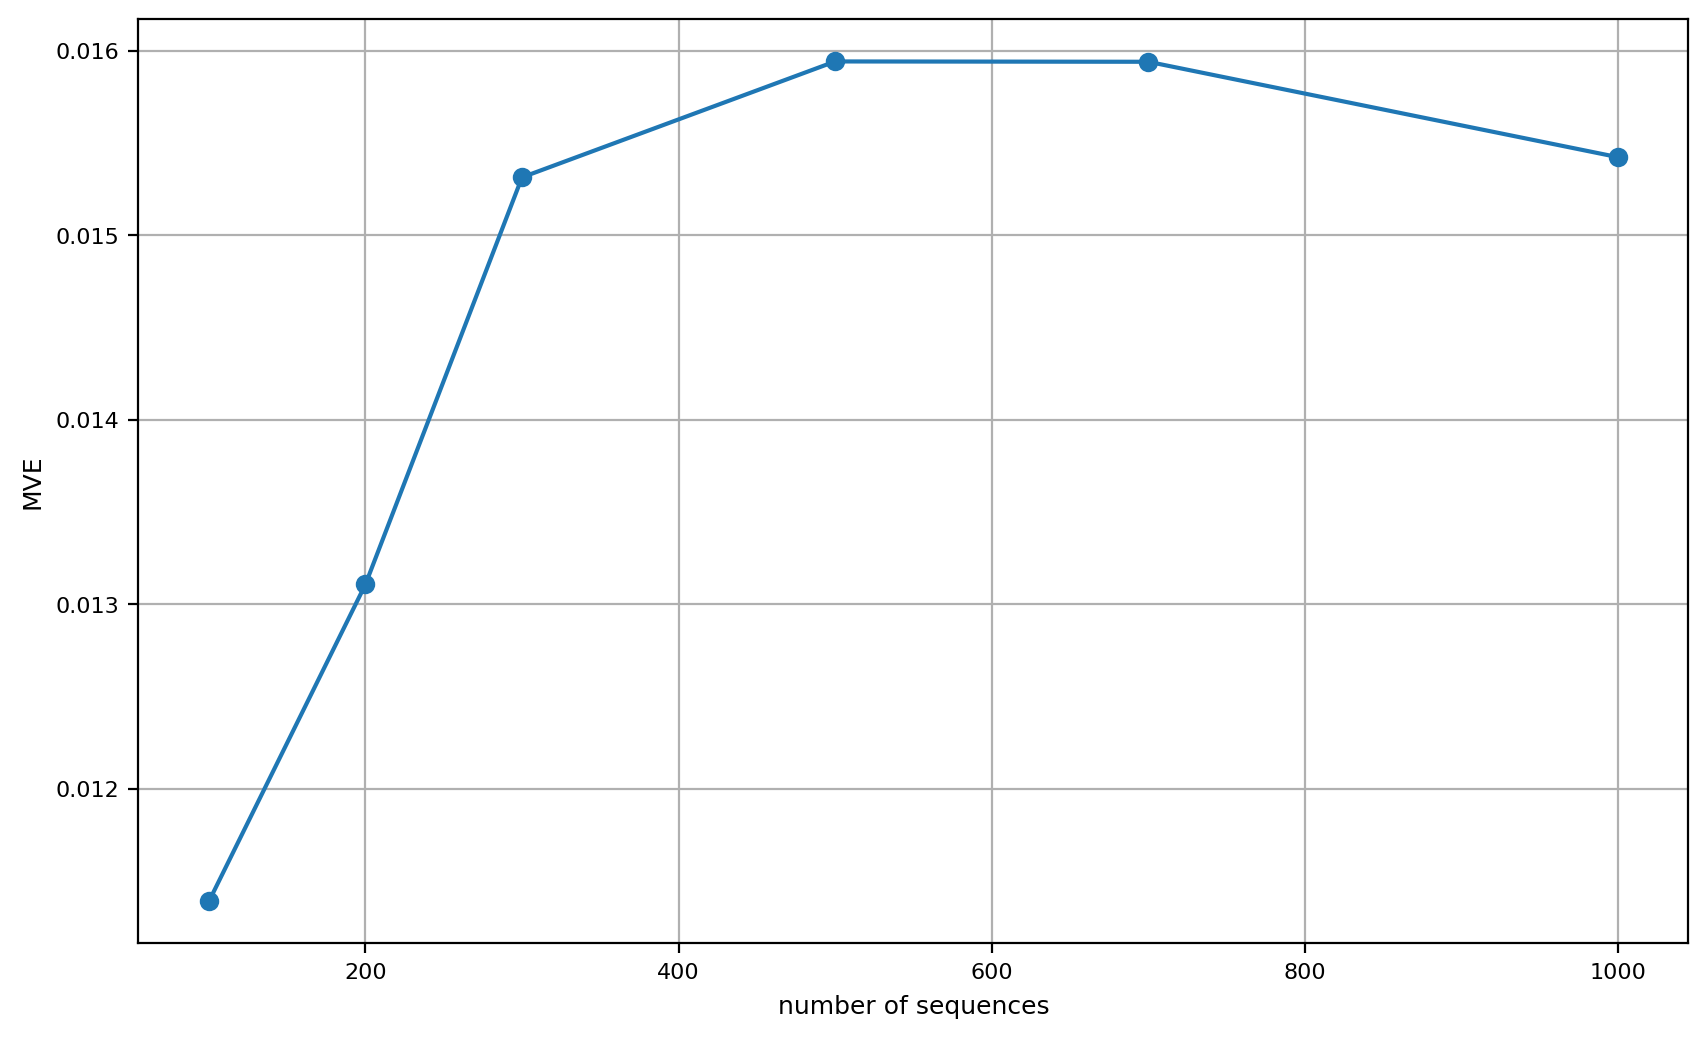

In [217]:
mve_values = [mve_100_seq, mve_200_seq, mve_300_seq, mve_500_seq, mve_700_seq ,mve_1000_seq_test]
num_sequences = [100, 200, 300, 500, 700, 1000]

plt.figure(figsize=(10, 6), dpi=200)
plt.plot(num_sequences, mve_values, marker='o')
plt.xlabel('number of sequences')
plt.ylabel('MVE')
plt.grid(True)
plt.show()

In [218]:
# can we do one for the mean diamond distance
def compute_mean_and_std(array:jnp.ndarray):
    """
    Compute the mean and standard deviation of a 1D array.
    """
    mean = jnp.mean(array)
    std = jnp.std(array)
    return mean, std

In [221]:
diamond_distances_vs_sequences = [
    diamond_distances_optimized_100_seq,
    diamond_distances_optimized_200_seq,
    diamond_distances_optimized_300_seq,
    diamond_distances_optimized_500_seq,
    diamond_distances_optimized_700_seq,
    diamond_distances_optimized_1000_seq
]

mean_std_diamond_distances = [compute_mean_and_std(jnp.array(distances)) for distances in diamond_distances_vs_sequences]

distances_dict = {str(num_seq): {"mean": mean, "std": std} for num_seq, (mean, std) in zip(num_sequences, mean_std_diamond_distances)}
distances_dict

{'100': {'mean': Array(0.02486532, dtype=float64),
  'std': Array(0.00520669, dtype=float64)},
 '200': {'mean': Array(0.01334195, dtype=float64),
  'std': Array(0.00179141, dtype=float64)},
 '300': {'mean': Array(0.0115606, dtype=float64),
  'std': Array(0.00187234, dtype=float64)},
 '500': {'mean': Array(0.00721602, dtype=float64),
  'std': Array(0.0017773, dtype=float64)},
 '700': {'mean': Array(0.00616785, dtype=float64),
  'std': Array(0.00126137, dtype=float64)},
 '1000': {'mean': Array(0.00564676, dtype=float64),
  'std': Array(0.00106431, dtype=float64)}}

In [226]:
from mGST.visualization import plot_mean_std_vs_x

2026-07-02 19:35:00,307 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-07-02 19:35:00,377 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


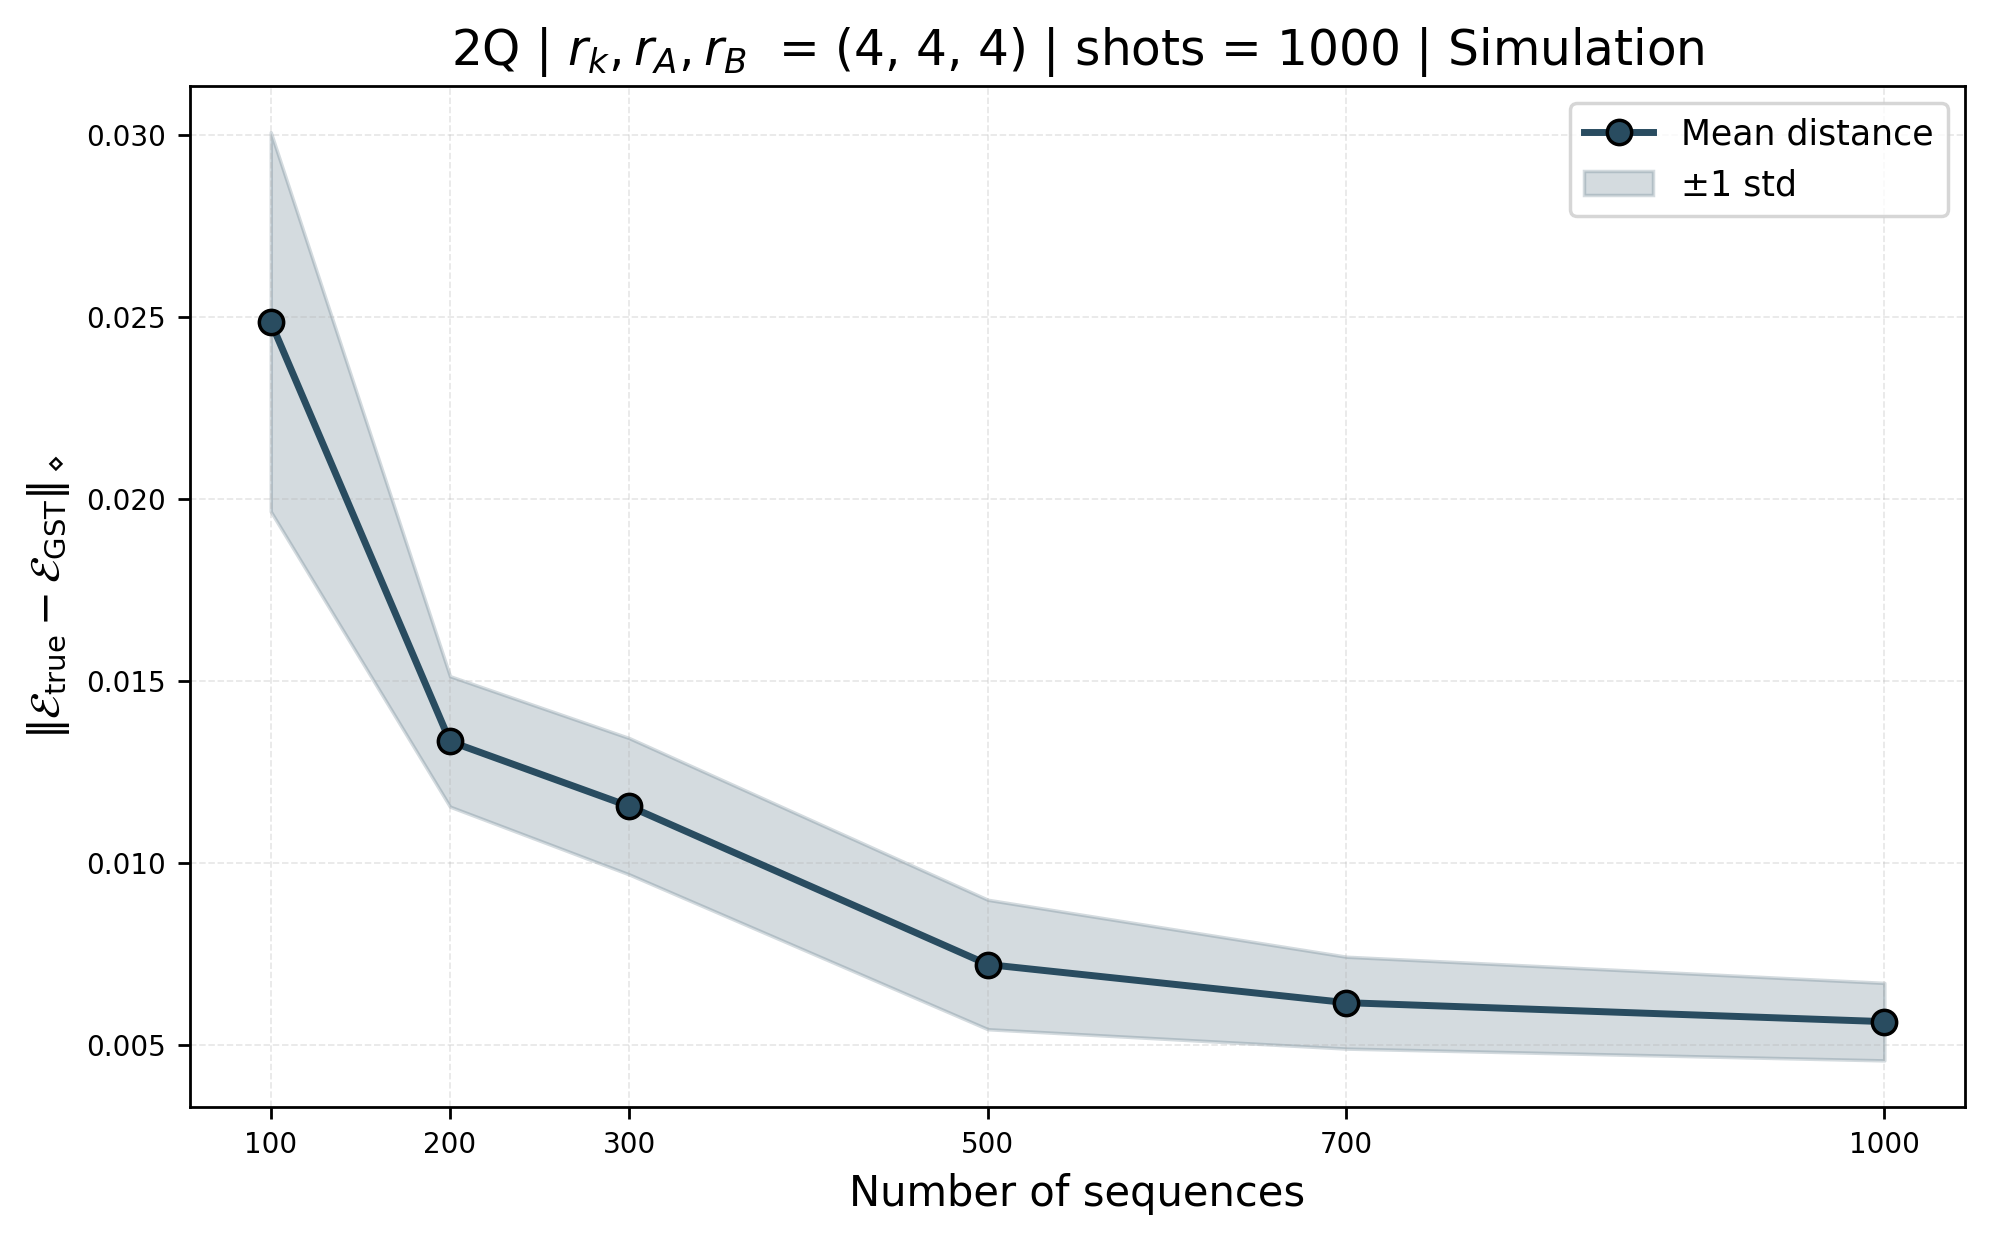

In [239]:
figure = plot_mean_std_vs_x(
    distances_dict,
    title=rf"2Q | $r_k, r_A, r_B$  = {kraus_rank, povm_rank, state_rank} | shots = {num_shots} | Simulation",
    ylabel=r"$\| \mathcal{E}_{\text{true}} - \mathcal{E}_{\text{GST}} \|_\diamond$",
    use_log_scale=False,
)